In [1]:
pip install pyarrow


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: /Users/bhavneet13/myenv/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
!pip install --upgrade pyarrow

In [24]:
df = pd.read_csv("05_Train_test&Scaling .csv")
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male,BalanceToSalary,ProductsPerYear,EngagementScore,AgeWhenJoined
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False,0.000000,0.333333,1,40
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False,0.744670,0.500000,1,40
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False,1.401362,0.333333,0,34
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False,0.000000,1.000000,0,38
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False,1.587035,0.333333,1,41


In [3]:
import pickle

with open("05_Train_test&Scaling .pkl", "rb") as f:
    X_train, X_test, y_train, y_test = pickle.load(f)

print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)
print("y_train churn rate:", round(y_train.mean() * 100, 2), "%")
print("y_test churn rate: ", round(y_test.mean()  * 100, 2), "%")

X_train: (7990, 15)
X_test:  (1998, 15)
y_train churn rate: 20.39 %
y_test churn rate:  20.37 %


In [4]:
import sys
!{sys.executable} -m pip install scikit-learn


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: /Users/bhavneet13/myenv/bin/python -m pip install --upgrade pip


In [5]:

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix


# Train
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train, y_train)

# Predict
y_pred_lr = lr_model.predict(X_test)

# Evaluate
print("Logistic Regression Results:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Results:
              precision    recall  f1-score   support

           0       0.83      0.96      0.89      1591
           1       0.62      0.25      0.36       407

    accuracy                           0.82      1998
   macro avg       0.73      0.61      0.63      1998
weighted avg       0.79      0.82      0.78      1998



In [6]:
from sklearn.tree import DecisionTreeClassifier

# Train
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Predict
y_pred_dt = dt_model.predict(X_test)

# Evaluate
print("Decision Tree Results:")
print(classification_report(y_test, y_pred_dt))

Decision Tree Results:
              precision    recall  f1-score   support

           0       0.88      0.86      0.87      1591
           1       0.50      0.53      0.51       407

    accuracy                           0.80      1998
   macro avg       0.69      0.70      0.69      1998
weighted avg       0.80      0.80      0.80      1998



In [7]:
from sklearn.ensemble import RandomForestClassifier

# Train
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)

# Evaluate
print("Random Forest Results:")
print(classification_report(y_test, y_pred_rf))

Random Forest Results:
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1591
           1       0.79      0.49      0.61       407

    accuracy                           0.87      1998
   macro avg       0.83      0.73      0.76      1998
weighted avg       0.86      0.87      0.86      1998



In [8]:
from sklearn.ensemble import GradientBoostingClassifier

# Train
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)

# Predict
y_pred_gb = gb_model.predict(X_test)

# Evaluate
print("Gradient Boosting Results:")
print(classification_report(y_test, y_pred_gb))

Gradient Boosting Results:
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1591
           1       0.79      0.49      0.60       407

    accuracy                           0.87      1998
   macro avg       0.83      0.73      0.76      1998
weighted avg       0.86      0.87      0.86      1998



In [9]:
pip install xgboost


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: /Users/bhavneet13/myenv/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [10]:
from xgboost import XGBClassifier

# Train
xgb_model = XGBClassifier(random_state=42, 
                           eval_metric="logloss")
xgb_model.fit(X_train, y_train)

# Predict
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate
print("XGBoost Results:")
print(classification_report(y_test, y_pred_xgb))

XGBoost Results:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1591
           1       0.75      0.50      0.60       407

    accuracy                           0.86      1998
   macro avg       0.81      0.73      0.76      1998
weighted avg       0.85      0.86      0.85      1998



In [11]:
from sklearn.metrics import roc_auc_score

print("ROC AUC Scores:")
print("Logistic Regression:", round(roc_auc_score(y_test, lr_model.predict_proba(X_test)[:,1]), 3))
print("Decision Tree:      ", round(roc_auc_score(y_test, dt_model.predict_proba(X_test)[:,1]), 3))
print("Random Forest:      ", round(roc_auc_score(y_test, rf_model.predict_proba(X_test)[:,1]), 3))
print("Gradient Boosting:  ", round(roc_auc_score(y_test, gb_model.predict_proba(X_test)[:,1]), 3))
print("XGBoost:            ", round(roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:,1]), 3))

ROC AUC Scores:
Logistic Regression: 0.765
Decision Tree:       0.697
Random Forest:       0.849
Gradient Boosting:   0.867
XGBoost:             0.843


<div class="alert alert-block alert-info">
    <h2><mark>🔍 Model Explainability</mark></h2>
    <p>This section breaks down how the machine learning model makes decisions, SHAP value analysis, Partial dependence plots</p>
</div>


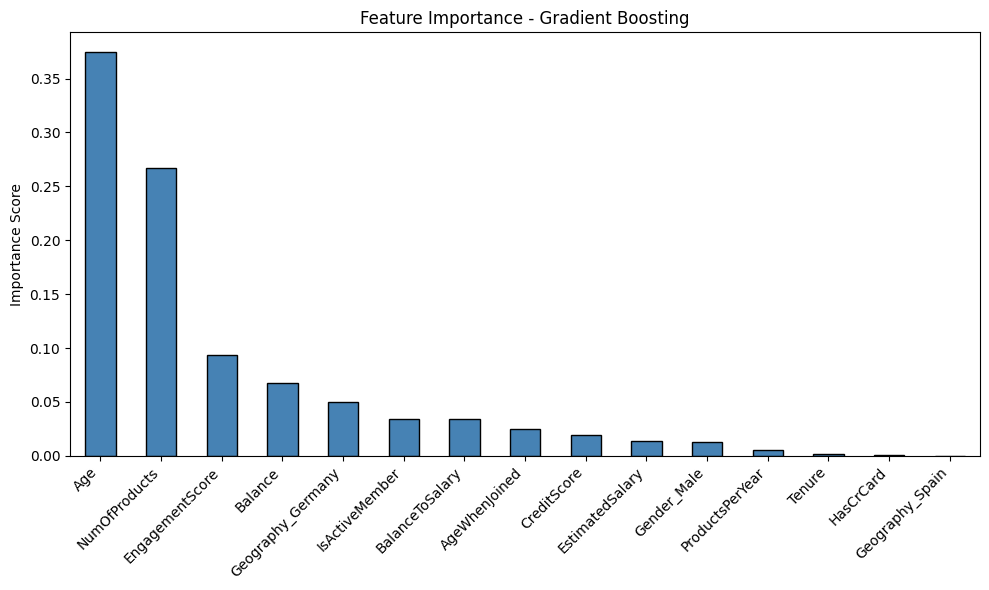

Age                  0.374124
NumOfProducts        0.266560
EngagementScore      0.093844
Balance              0.067796
Geography_Germany    0.050358
IsActiveMember       0.034189
BalanceToSalary      0.033951
AgeWhenJoined        0.025101
CreditScore          0.019450
EstimatedSalary      0.013883
Gender_Male          0.013232
ProductsPerYear      0.005202
Tenure               0.001787
HasCrCard            0.000446
Geography_Spain      0.000078
dtype: float64


In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Feature importance from Gradient Boosting (best ROC AUC)
importance = pd.Series(gb_model.feature_importances_,
                       index=X_train.columns)
importance = importance.sort_values(ascending=False)

# Plot
plt.figure(figsize=(10, 6))
importance.plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Feature Importance - Gradient Boosting")
plt.ylabel("Importance Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print(importance)

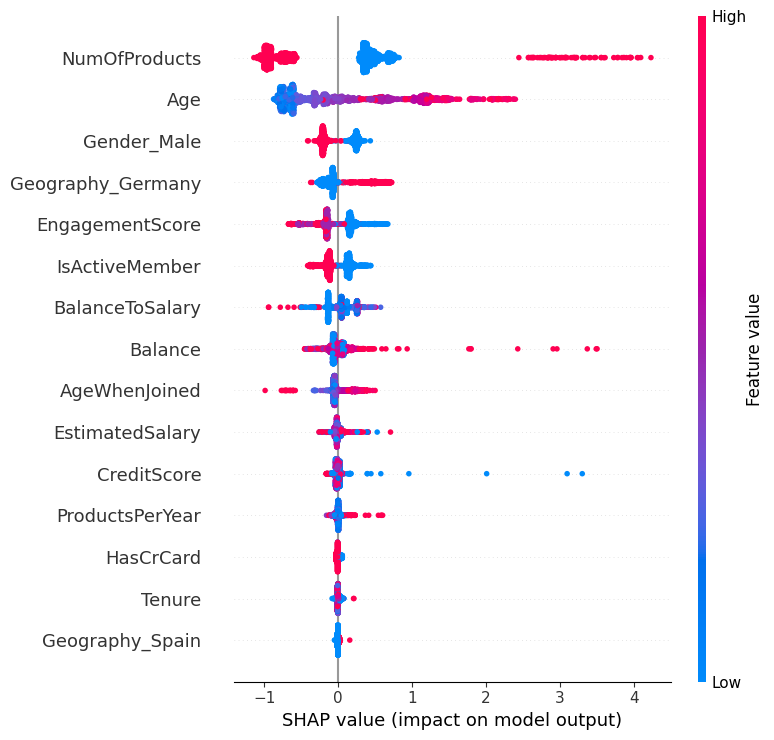

In [13]:
import shap

# Create explainer
explainer = shap.TreeExplainer(gb_model)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test)

# Summary plot
shap.summary_plot(shap_values, 
                  X_test,
                  feature_names=X_train.columns.tolist())

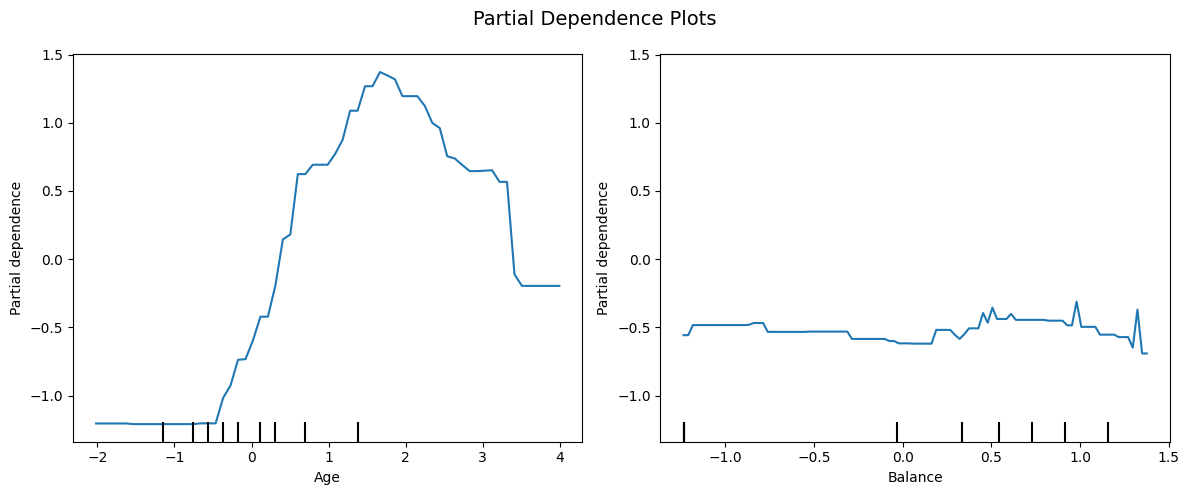

In [14]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

PartialDependenceDisplay.from_estimator(
    gb_model, 
    X_train,
    features=["Age", "Balance"],
    feature_names=X_train.columns.tolist(),
    ax=ax)

plt.suptitle("Partial Dependence Plots", fontsize=14)
plt.tight_layout()
plt.show()

In [15]:
# Get probability score for each customer
y_prob = gb_model.predict_proba(X_test)[:,1]
print(y_prob[:10])

[0.02232733 0.01927846 0.03212869 0.13819666 0.04937607 0.33351271
 0.05936422 0.53999303 0.05521387 0.22263866]


In [16]:
# Default threshold = 0.5
y_pred = gb_model.predict(X_test)

# Custom threshold = 0.3 (catch more churners)
y_pred_custom = (y_prob >= 0.3).astype(int)

# Compare both
print("Default threshold (0.5):")
print(classification_report(y_test, y_pred))

print("Custom threshold (0.3):")
print(classification_report(y_test, y_pred_custom))

Default threshold (0.5):
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1591
           1       0.79      0.49      0.60       407

    accuracy                           0.87      1998
   macro avg       0.83      0.73      0.76      1998
weighted avg       0.86      0.87      0.86      1998

Custom threshold (0.3):
              precision    recall  f1-score   support

           0       0.91      0.90      0.91      1591
           1       0.63      0.64      0.63       407

    accuracy                           0.85      1998
   macro avg       0.77      0.77      0.77      1998
weighted avg       0.85      0.85      0.85      1998



In [17]:
# Model already trained
# Just get probabilities
y_prob = gb_model.predict_proba(X_test)[:,1]

# Change threshold anytime you want!
y_pred_03 = (y_prob >= 0.3).astype(int)
y_pred_04 = (y_prob >= 0.4).astype(int)
y_pred_05 = (y_prob >= 0.5).astype(int)

# Print all three
print("Threshold 0.3:")
print(classification_report(y_test, y_pred_03))

print("Threshold 0.4:")
print(classification_report(y_test, y_pred_04))

print("Threshold 0.5:")
print(classification_report(y_test, y_pred_05))

Threshold 0.3:
              precision    recall  f1-score   support

           0       0.91      0.90      0.91      1591
           1       0.63      0.64      0.63       407

    accuracy                           0.85      1998
   macro avg       0.77      0.77      0.77      1998
weighted avg       0.85      0.85      0.85      1998

Threshold 0.4:
              precision    recall  f1-score   support

           0       0.89      0.94      0.92      1591
           1       0.72      0.56      0.63       407

    accuracy                           0.86      1998
   macro avg       0.80      0.75      0.77      1998
weighted avg       0.86      0.86      0.86      1998

Threshold 0.5:
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1591
           1       0.79      0.49      0.60       407

    accuracy                           0.87      1998
   macro avg       0.83      0.73      0.76      1998
weighted avg       0.86      

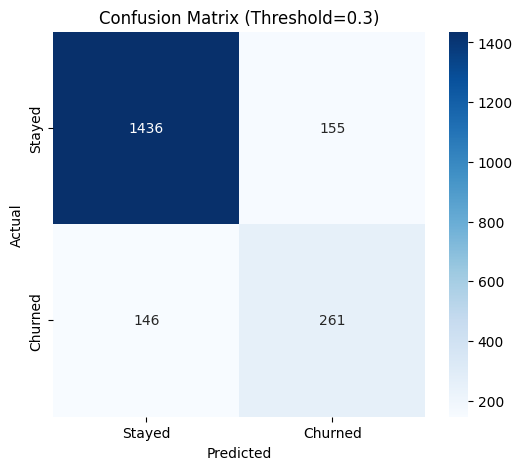

[[1436  155]
 [ 146  261]]


In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_custom)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Stayed", "Churned"],
            yticklabels=["Stayed", "Churned"])

plt.title("Confusion Matrix (Threshold=0.3)")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

print(cm)

In [25]:

# Save cleaned dataframe as CSV
df.to_csv("06_modeling.csv", index=False)
print("Saved successfully!")


Saved successfully!


In [26]:
import pickle

with open("06_modelling.pkl", "wb") as f:
    pickle.dump(gb_model, f)

print("Model saved!")

Model saved!


In [28]:
with open("trained_models.pkl", "wb") as f:
    pickle.dump(gb_model, f)

print("Model saved!")

Model saved!
